In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [8]:
# Airplane Crashes data cleaning exercise

# Question 2: Determine the number of rows and columns in the dataset

rows = df.shape[0]
columns = df.shape[1]

RowsAndColumns= df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)
print(RowsAndColumns)


Number of rows: 5268
Number of columns: 13
(5268, 13)


In [9]:
# Question 2: Display the last 75 rows in the dataset

df.tail(75)


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [20]:
#Create a new dataframe from the raw/uncleaned data called ‘fatality_locations’ with the following columns: ‘Date’, ‘Location’, ‘Aboard’, ‘Fatalities’. 
fatality_locations=df[["Date","Location","Aboard","Fatalities"]].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [11]:
#Determine the date of the highest number of recorded fatalities from this new dataframe. 

highest_fatalities=df["Fatalities"].max()
print(highest_fatalities)

highest_date=df.loc[highest_fatalities, "Date"]
print(highest_date)


583.0
05/12/1942


In [21]:
#8. In the ‘fatality_locations’ dataframe, the location column has data items represented as ‘Region, U.S. State/Country’. Split this column to have two columns of regions and states/countries. 
fatality_locations[["Region","U.S State/country"]]=fatality_locations["Location"].str.split(",",n=1, expand=True)
print(fatality_locations)

            Date                                           Location  Aboard  \
0     09/17/1908                                Fort Myer, Virginia     2.0   
1     07/12/1912                            AtlantiCity, New Jersey     5.0   
2     08/06/1913                 Victoria, British Columbia, Canada     1.0   
3     09/09/1913                                 Over the North Sea    20.0   
4     10/17/1913                         Near Johannisthal, Germany    30.0   
...          ...                                                ...     ...   
5263  05/20/2009                             Near Madiun, Indonesia   112.0   
5264  05/26/2009                  Near Isiro, DemocratiRepubliCongo     4.0   
5265  06/01/2009  AtlantiOcean, 570 miles northeast of Natal, Br...   228.0   
5266  06/07/2009       Near Port Hope Simpson, Newfoundland, Canada     1.0   
5267  06/08/2009                  State of Arunachal Pradesh, India    13.0   

      Fatalities                      Region  \
0  

In [13]:
#Order the dataframe by the number of fatalities from highest to lowest and select the first 100. 
top100fatalities= df.sort_values(by="Fatalities", ascending=False).head(100)
print(top100fatalities)

            Date   Time                                    Location  \
2963  03/27/1977  17:07                    Tenerife, Canary Islands   
3568  08/12/1985  18:56       Mt. Osutaka, near Ueno Village, Japan   
4455  11/12/1996  18:40                    Near Charkhidadri, India   
2726  03/03/1974  11:41                   Near Ermenonville, France   
3562  06/23/1985  07:15     AtlantiOcean, 110 miles West of Ireland   
...          ...    ...                                         ...   
4852  04/15/2002  11:23                          Busan, South Korea   
3198  01/21/1980  19:10  Elburz Mtns., near Laskarak, Markazi, Iran   
1701  12/16/1960  10:33          Staten Island / Brooklyn, New York   
5108  07/09/2006  07:44                             Irkutsk, Russia   
1433  06/30/1956  10:32                       Grand Canyon, Arizona   

                                        Operator   Flight #  \
2963            Pan American World Airways / KLM  1736/4805   
3568                 

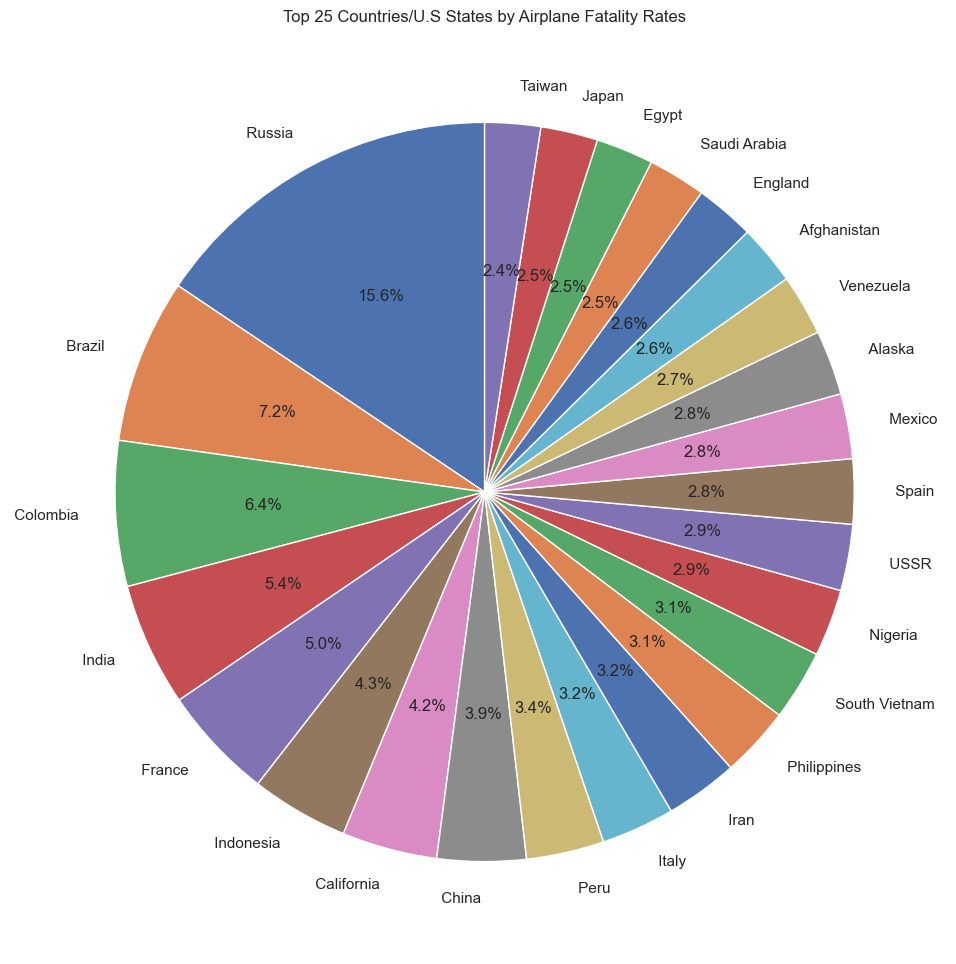

In [24]:

top25fatalities = (
    fatality_locations
    .groupby("U.S State/country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

sns.set_theme()

plt.figure(figsize=(12, 12))

plt.pie(
    top25fatalities,
    labels=top25fatalities.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 25 Countries/U.S States by Airplane Fatality Rates")

plt.show()